# 서울 조달 입찰공고 탐색적 데이터 분석 (EDA)

**목적:** 수집된 공공조달 데이터의 분포, 품질, 패턴을 확인합니다.  
**데이터:** 조달청 나라장터 입찰공고 (서울 6개 자치구, 최근 180일)  
**핵심 질문:**
1. 자치구별 공고 수와 금액 규모는 어떻게 다른가?
2. 품목군 분류는 충분한가? 기타 비율은 적절한가?
3. 인구 보정 전후로 순위가 어떻게 달라지는가?
4. 어떤 품목군이 어떤 지역에 집중되어 있는가?

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 5)

print('라이브러리 로드 완료')

라이브러리 로드 완료


In [2]:
cleaned = pd.read_csv('../data/processed/seoul_bid_cleaned.csv', encoding='utf-8-sig')
matrix  = pd.read_csv('../outputs/tables/seoul_opportunity_matrix.csv', encoding='utf-8-sig')
features = pd.read_csv('../outputs/tables/seoul_feature_table.csv', encoding='utf-8-sig')

print(f'정제 데이터: {len(cleaned)}행')
print(f'매트릭스:   {len(matrix)}행 ({matrix["district"].nunique()}개 구 × {matrix["item_category"].nunique()}개 품목군)')
print(f'피처 테이블: {len(features)}행')

정제 데이터: 555행
매트릭스:   77행 (7개 구 × 16개 품목군)
피처 테이블: 77행


## 1. 자치구별 공고 수 분포

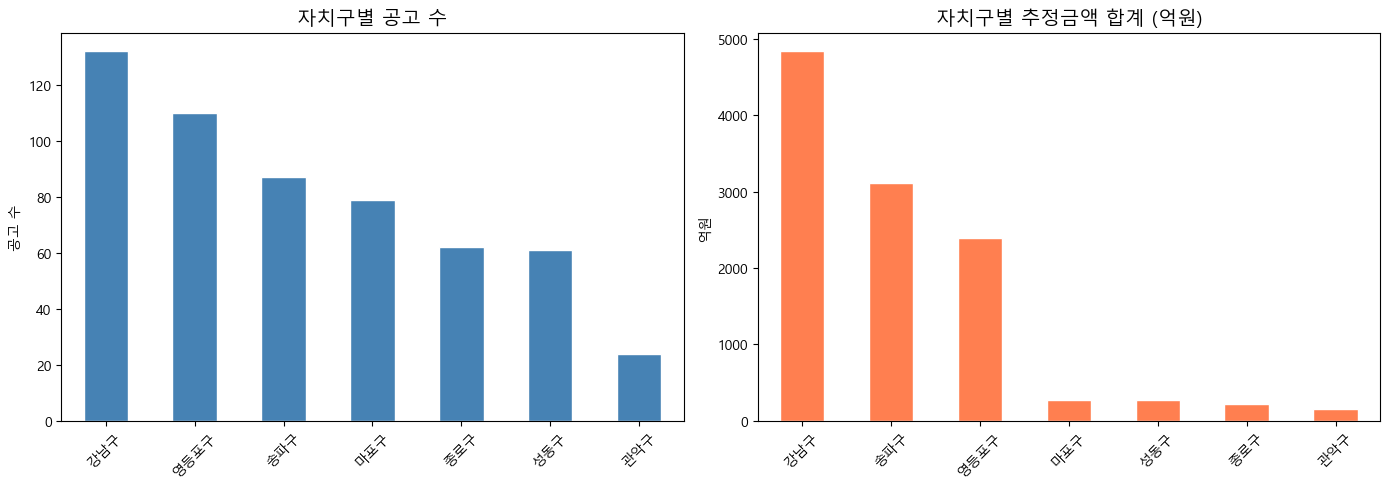

인사이트: 영등포구·송파구는 공고 수가 많고, 강남구는 금액 규모가 크다.


In [3]:
district_counts = cleaned['district'].value_counts()
district_counts = district_counts[district_counts.index != '미상']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 공고 수
district_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('자치구별 공고 수', fontsize=14)
axes[0].set_xlabel('')
axes[0].set_ylabel('공고 수')
axes[0].tick_params(axis='x', rotation=45)

# 금액 합계
amount_by_dist = (
    cleaned[cleaned['district'] != '미상']
    .groupby('district')['estimated_amount']
    .sum()
    .sort_values(ascending=False)
)
(amount_by_dist / 1e8).plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('자치구별 추정금액 합계 (억원)', fontsize=14)
axes[1].set_xlabel('')
axes[1].set_ylabel('억원')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../outputs/figures/eda_district_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('인사이트: 영등포구·송파구는 공고 수가 많고, 강남구는 금액 규모가 크다.')

## 2. 품목군 분포 및 기타 비율

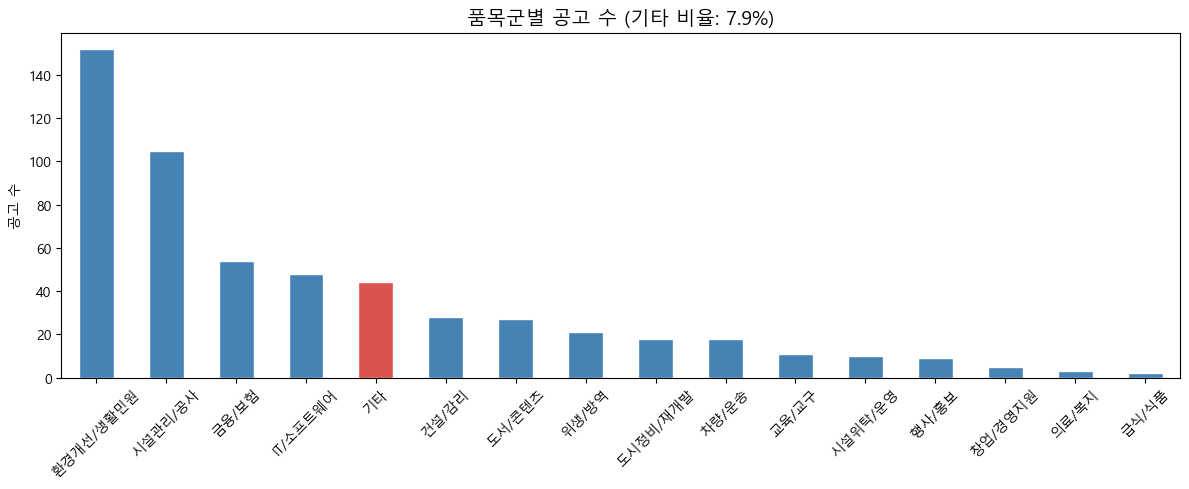

기타 비율: 7.9% → 분류된 비율: 92.1%
인사이트: 환경개선/시설관리가 공공조달의 핵심 품목군임을 알 수 있다.


In [4]:
cat_counts = cleaned['item_category'].value_counts()
other_ratio = cat_counts.get('기타', 0) / len(cleaned) * 100

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#d9534f' if c == '기타' else 'steelblue' for c in cat_counts.index]
cat_counts.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title(f'품목군별 공고 수 (기타 비율: {other_ratio:.1f}%)', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('공고 수')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../outputs/figures/eda_category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'기타 비율: {other_ratio:.1f}% → 분류된 비율: {100-other_ratio:.1f}%')
print('인사이트: 환경개선/시설관리가 공공조달의 핵심 품목군임을 알 수 있다.')

## 3. 인구 보정 전후 순위 변화

**핵심 질문:** 공고 수가 많은 구가 인구 대비로도 높은가, 아니면 단순히 기관이 많아서인가?

In [5]:
# 자치구별 전체 공고 수 기준 순위 vs 인구 보정 순위
dist_summary = (
    features.groupby('district')
    .agg(
        total_bids=('bid_count', 'sum'),
        avg_per_10k=('bids_per_10k_population', 'mean'),
    )
    .reset_index()
)

dist_summary['rank_raw'] = dist_summary['total_bids'].rank(ascending=False).astype(int)
dist_summary['rank_normalized'] = dist_summary['avg_per_10k'].rank(ascending=False).astype(int)
dist_summary['rank_change'] = dist_summary['rank_raw'] - dist_summary['rank_normalized']

print('자치구별 순위 비교 (보정 전 vs 보정 후):')
print(dist_summary[['district','total_bids','rank_raw','avg_per_10k','rank_normalized','rank_change']]
      .sort_values('rank_raw').to_string(index=False))
print()
print('인사이트: rank_change > 0 = 인구 보정 후 순위 하락 (절대 수는 많지만 밀도는 낮음)')
print('         rank_change < 0 = 인구 보정 후 순위 상승 (인구 대비 수요 집중도 높음)')

자치구별 순위 비교 (보정 전 vs 보정 후):
district  total_bids  rank_raw  avg_per_10k  rank_normalized  rank_change
     강남구         132         1     0.167627                5           -4
    영등포구         110         2     0.221362                2            0
     송파구          87         3     0.131050                6           -3
     마포구          79         4     0.214080                3            1
     종로구          62         5     0.363875                1            4
     성동구          61         6     0.197055                4            2
     관악구          24         7     0.082067                7            0

인사이트: rank_change > 0 = 인구 보정 후 순위 하락 (절대 수는 많지만 밀도는 낮음)
         rank_change < 0 = 인구 보정 후 순위 상승 (인구 대비 수요 집중도 높음)


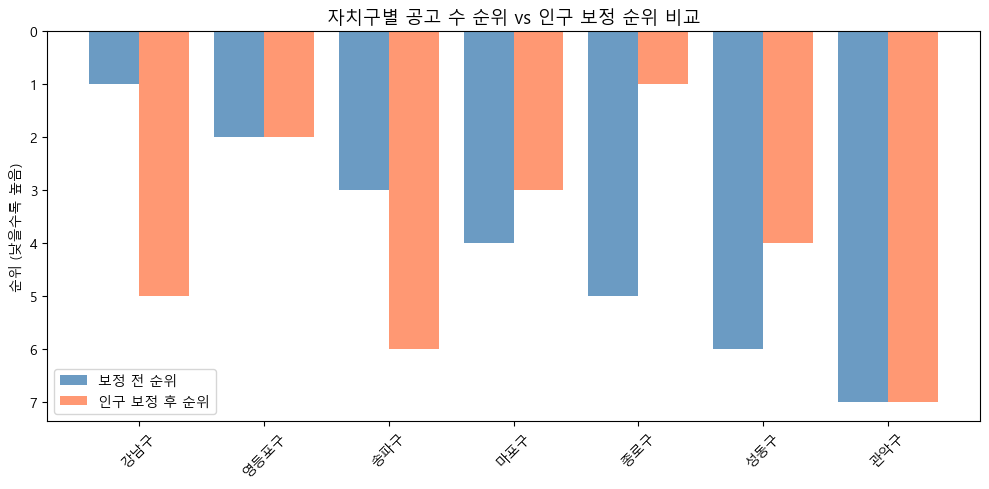

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

x = range(len(dist_summary))
dist_sorted = dist_summary.sort_values('rank_raw')

ax.bar([i - 0.2 for i in x], dist_sorted['rank_raw'], width=0.4, label='보정 전 순위', color='steelblue', alpha=0.8)
ax.bar([i + 0.2 for i in x], dist_sorted['rank_normalized'], width=0.4, label='인구 보정 후 순위', color='coral', alpha=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(dist_sorted['district'], rotation=45)
ax.set_ylabel('순위 (낮을수록 높음)')
ax.set_title('자치구별 공고 수 순위 vs 인구 보정 순위 비교', fontsize=13)
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/figures/eda_rank_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 지역 × 품목군 히트맵 분석

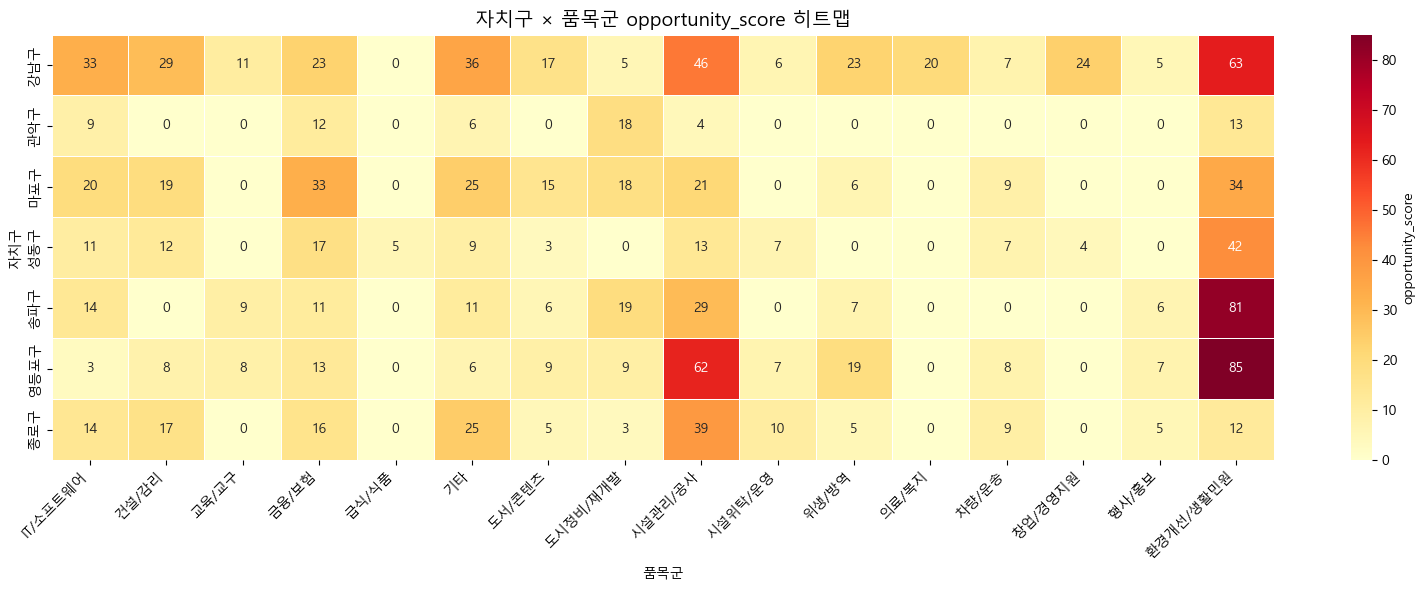

인사이트: 환경개선/시설관리 수요는 전 자치구에 걸쳐 있으나, IT/소프트웨어는 강남구에 집중된다.


In [7]:
pivot = matrix.pivot_table(
    index='district', columns='item_category',
    values='opportunity_score', fill_value=0
)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    pivot, annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'opportunity_score'}
)
ax.set_title('자치구 × 품목군 opportunity_score 히트맵', fontsize=14)
ax.set_xlabel('품목군')
ax.set_ylabel('자치구')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/figures/eda_heatmap_full.png', dpi=150, bbox_inches='tight')
plt.show()
print('인사이트: 환경개선/시설관리 수요는 전 자치구에 걸쳐 있으나, IT/소프트웨어는 강남구에 집중된다.')

## 5. 발견한 주요 인사이트 3가지

1. **수요 밀도 vs 규모의 차이**  
   영등포구·송파구는 공고 수 절대값이 높지만, 인구 1만 명 당 공고 수로 보정하면 종로구의 집중도가 상대적으로 높아진다.  
   → *큰 구가 무조건 좋은 입지가 아니라, 수요 밀도가 높은 지역이 재고 효율에 유리할 수 있다.*

2. **환경개선/시설관리의 보편성**  
   모든 자치구에서 환경개선/생활민원과 시설관리/공사가 상위에 나타난다.  
   → *지역에 관계없이 안정적 수요가 있는 품목군. 재고회전 관점에서 낮은 리스크.*

3. **강남구 IT/소프트웨어의 집중**  
   IT/소프트웨어 수요는 강남구에서 두드러진다 (업무지구/IT 이미지와 일치).  
   → *업종 특화 수요 지역을 확인할 수 있다는 이 분석의 핵심 가치.*

---

**한계 및 다음 단계**
- 현재는 공공수요(조달)만 반영. 민간 소비수요(상권), 경쟁 포화도(사업체수)는 미포함.
- 낙찰정보 API를 붙이면 "공고 후 낙찰까지 며칠"(수요 즉시성) 지표 추가 가능.
- 인구 보정 지표를 opportunity_score에 통합하는 v2 점수 설계 가능.